In [1]:
import torch
print("GPU Available:", torch.cuda.is_available())

GPU Available: True


In [2]:
!pip install diffusers transformers accelerate safetensors --quiet

In [3]:
import torch
from diffusers import StableDiffusionPipeline
import os
import matplotlib.pyplot as plt

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [4]:
model_id = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    safety_checker=None
)

pipe = pipe.to("cuda")
pipe.enable_attention_slicing()

print("Model loaded successfully")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its resul

Model loaded successfully


In [5]:
prompts = [
    "A futuristic smart city at night with neon lights, ultra realistic, 4k",
    "A peaceful mountain lake during sunset, cinematic lighting",
    "A cute astronaut cat floating in space, digital art",
    "A vintage steam train crossing a stone bridge in autumn",
    "A humanoid robot playing chess in a quiet park, highly detailed"
]

In [6]:
output_folder = "synthetic_dataset"
os.makedirs(output_folder, exist_ok=True)

In [7]:
generated_images = []

for i, prompt in enumerate(prompts):
    print(f"Generating image {i+1} ...")

    image = pipe(
        prompt,
        num_inference_steps=30,
        guidance_scale=7.5
    ).images[0]

    image.save(f"{output_folder}/sample_{i+1}.png")
    generated_images.append(image)

print("Dataset generated successfully")

Generating image 1 ...


  0%|          | 0/30 [00:00<?, ?it/s]

Generating image 2 ...


  0%|          | 0/30 [00:00<?, ?it/s]

Generating image 3 ...


...

Generating image 4 ...


  0%|          | 0/30 [00:00<?, ?it/s]

Generating image 5 ...


  0%|          | 0/30 [00:00<?, ?it/s]

Dataset generated successfully


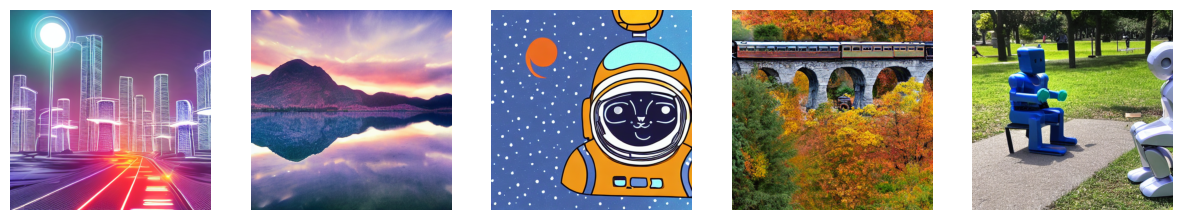

In [8]:
plt.figure(figsize=(15,5))
for i, img in enumerate(generated_images):
    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.axis("off")
plt.show()

In [9]:
!zip -r synthetic_dataset.zip synthetic_dataset

  adding: synthetic_dataset/ (stored 0%)
  adding: synthetic_dataset/sample_1.png (deflated 0%)
  adding: synthetic_dataset/sample_3.png (deflated 0%)
  adding: synthetic_dataset/sample_4.png (deflated 0%)
  adding: synthetic_dataset/sample_2.png (deflated 0%)
  adding: synthetic_dataset/sample_5.png (deflated 0%)
